In [1]:
# Basic imports for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show all columns in notebook output
pd.set_option("display.max_columns", None)

In [2]:
from pathlib import Path

# Project root and raw data folder
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Load datasets
customers = pd.read_csv(DATA_DIR / "customers.csv")
policies = pd.read_csv(DATA_DIR / "policies.csv")
claims = pd.read_csv(DATA_DIR / "claims.csv")
premiums = pd.read_csv(DATA_DIR / "premiums.csv")
renewals = pd.read_csv(DATA_DIR / "renewals.csv")
underwriting = pd.read_csv(DATA_DIR / "underwriting.csv")
agents = pd.read_csv(DATA_DIR / "agents.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [3]:
# Check numeric customer columns
customers[
    ["AGE", "ANNUAL_INCOME", "CREDIT_SCORE"]
].describe()

,AGE,ANNUAL_INCOME,CREDIT_SCORE
count,100000.000000,1.000000e+05,100000.000000
mean,38.671880,8.311229e+05,719.502090
std,11.513542,6.567305e+05,69.892151
min,18.000000,1.200000e+05,450.000000
25%,30.000000,4.065565e+05,672.000000
50%,38.000000,6.493635e+05,720.000000
75%,47.000000,1.044275e+06,767.000000
max,80.000000,8.000000e+06,900.000000


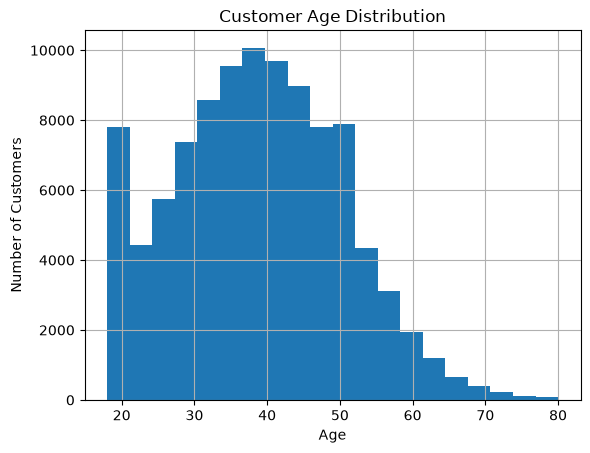

In [4]:
# Age distribution
customers["AGE"].hist(bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

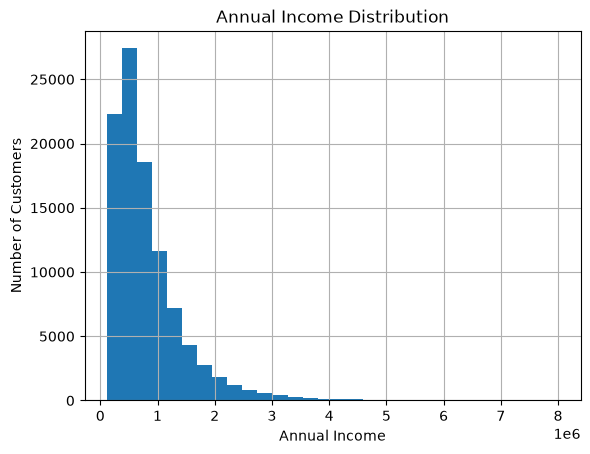

In [5]:
# Income distribution
customers["ANNUAL_INCOME"].hist(bins=30)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")
plt.show()

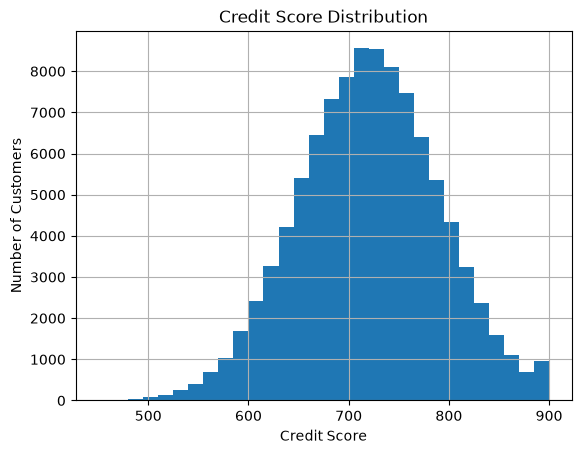

In [6]:
# Credit score distribution
customers["CREDIT_SCORE"].hist(bins=30)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.show()

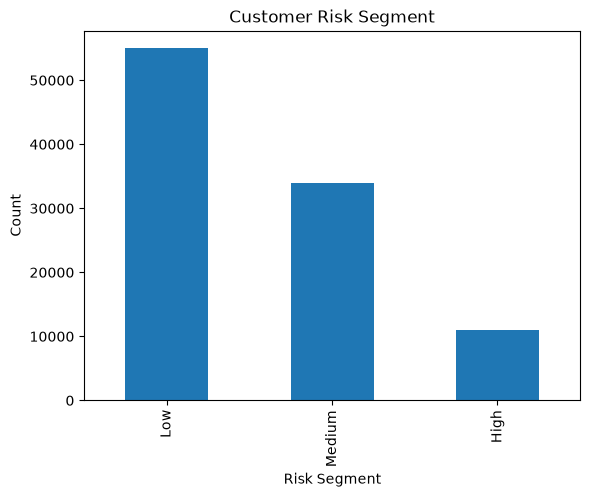

In [7]:
# Customer risk segment distribution
customers["CUSTOMER_RISK_SEGMENT"].value_counts().plot(kind="bar")

plt.title("Customer Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Count")
plt.show()

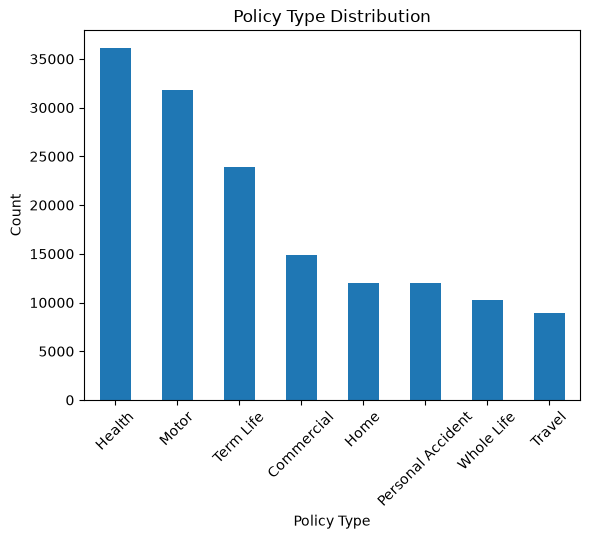

In [8]:
# Policy type distribution
policies["POLICY_TYPE"].value_counts().plot(kind="bar")

plt.title("Policy Type Distribution")
plt.xlabel("Policy Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

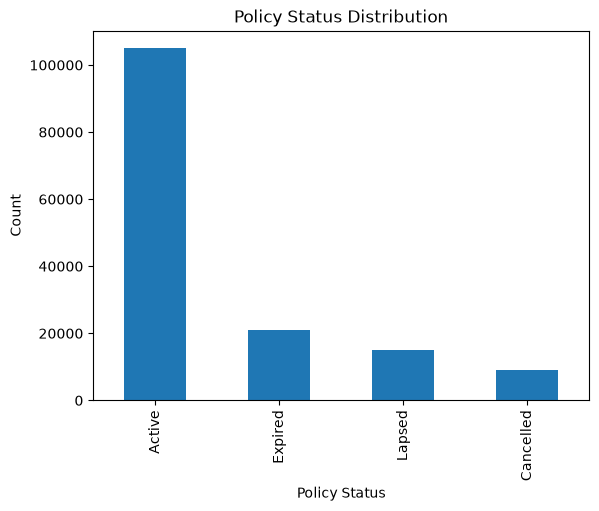

In [9]:
# Policy status distribution
policies["POLICY_STATUS"].value_counts().plot(kind="bar")

plt.title("Policy Status Distribution")
plt.xlabel("Policy Status")
plt.ylabel("Count")
plt.show()

In [10]:
# Check fraud class distribution
claims["FRAUD_FLAG"].value_counts()

FRAUD_FLAG
No           72841
Suspected     1815
Confirmed      344
Name: count, dtype: int64

In [11]:
# Fraud class percentage
fraud_pct = claims["FRAUD_FLAG"].value_counts(normalize=True) * 100

fraud_pct

FRAUD_FLAG
No           97.121333
Suspected     2.420000
Confirmed     0.458667
Name: proportion, dtype: float64

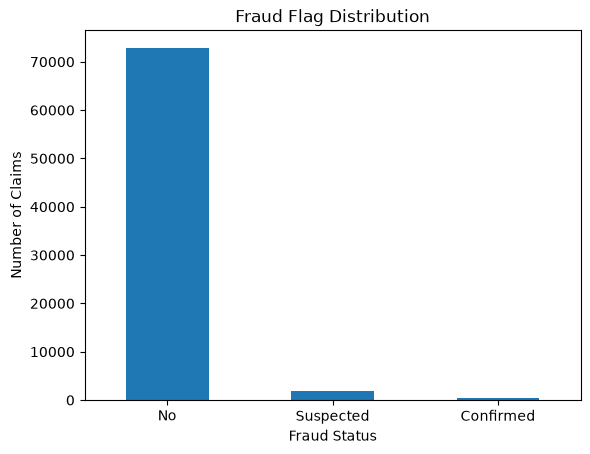

In [12]:
# Plot fraud distribution
claims["FRAUD_FLAG"].value_counts().plot(kind="bar")

plt.title("Fraud Flag Distribution")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.show()

In [13]:
# Fraud score summary by fraud status
claims.groupby("FRAUD_FLAG")["FRAUD_SCORE"].describe()

,count,mean,std,min,25%,50%,75%,max
FRAUD_FLAG,,,,,,,,
Confirmed,344.0,0.519148,0.292521,0.0024,0.282925,0.5299,0.7846,0.9965
No,72841.0,0.498087,0.288420,0.0000,0.247500,0.4983,0.7480,1.0000
Suspected,1815.0,0.505744,0.285908,0.0017,0.263300,0.5025,0.7521,0.9995


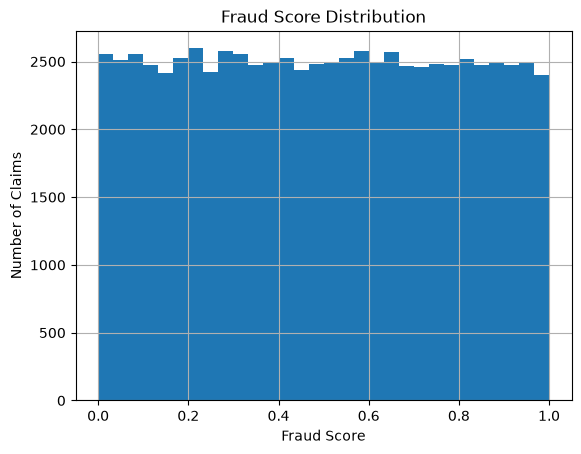

In [14]:
# Fraud score distribution
claims["FRAUD_SCORE"].hist(bins=30)

plt.title("Fraud Score Distribution")
plt.xlabel("Fraud Score")
plt.ylabel("Number of Claims")
plt.show()

In [15]:
# Claim amount summary
claims["CLAIM_AMOUNT"].describe()

count    7.500000e+04
mean     3.063485e+05
std      6.084179e+05
min      2.000000e+03
25%      4.103175e+04
50%      1.090645e+05
75%      3.112128e+05
max      1.599195e+07
Name: CLAIM_AMOUNT, dtype: float64

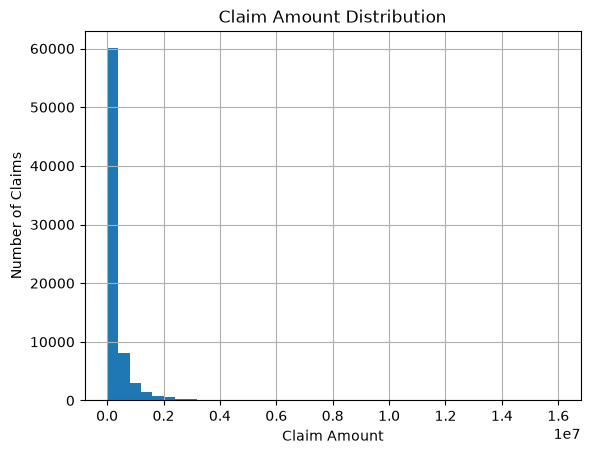

In [16]:
# Claim amount distribution
claims["CLAIM_AMOUNT"].hist(bins=40)

plt.title("Claim Amount Distribution")
plt.xlabel("Claim Amount")
plt.ylabel("Number of Claims")
plt.show()

In [17]:
# Average claim amount for each fraud class
claims.groupby("FRAUD_FLAG")["CLAIM_AMOUNT"].mean()

FRAUD_FLAG
Confirmed    462553.427326
No           301988.501709
Suspected    451719.963085
Name: CLAIM_AMOUNT, dtype: float64

In [18]:
# Compare claim amount statistics across fraud classes
claims.groupby("FRAUD_FLAG")["CLAIM_AMOUNT"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
FRAUD_FLAG,,,,,
Confirmed,344,462553.427326,154605.5,3984,7287564
No,72841,301988.501709,107832.0,2000,15991949
Suspected,1815,451719.963085,164360.0,2670,8303070


In [19]:
# Check renewal target distribution
renewals["RENEWAL_STATUS"].value_counts()

RENEWAL_STATUS
Renewed      17334
Lapsed        1463
Pending        796
Cancelled      407
Name: count, dtype: int64

In [20]:
# Renewal percentage distribution
renewals["RENEWAL_STATUS"].value_counts(normalize=True) * 100

RENEWAL_STATUS
Renewed      86.670
Lapsed        7.315
Pending       3.980
Cancelled     2.035
Name: proportion, dtype: float64

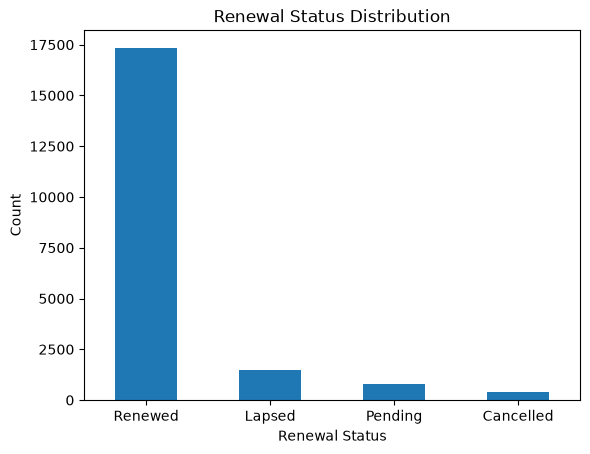

In [21]:
# Plot renewal status distribution
renewals["RENEWAL_STATUS"].value_counts().plot(kind="bar")

plt.title("Renewal Status Distribution")
plt.xlabel("Renewal Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [22]:
# Compare old and new premium
renewals[["OLD_PREMIUM", "NEW_PREMIUM"]].describe()

,OLD_PREMIUM,NEW_PREMIUM
count,20000.000000,20000.000000
mean,19331.410950,20699.031200
std,14301.803015,15378.435784
min,1200.000000,1217.000000
25%,10456.250000,11146.250000
50%,15608.500000,16718.500000
75%,23354.000000,25069.250000
max,145470.000000,161195.000000


In [23]:
# Calculate percentage increase in premium
renewals["PREMIUM_INCREASE_PCT"] = (
    (renewals["NEW_PREMIUM"] - renewals["OLD_PREMIUM"])
    / renewals["OLD_PREMIUM"]
) * 100

In [24]:
# Premium increase summary
renewals["PREMIUM_INCREASE_PCT"].describe()

count    20000.000000
mean         7.037202
std          4.954253
min        -11.201902
25%          3.678688
50%          7.066720
75%         10.407734
max         33.358237
Name: PREMIUM_INCREASE_PCT, dtype: float64

In [25]:
# Average premium increase by renewal status
renewals.groupby("RENEWAL_STATUS")["PREMIUM_INCREASE_PCT"].mean()

RENEWAL_STATUS
Cancelled    7.943526
Lapsed       8.442318
Pending      7.932234
Renewed      6.856228
Name: PREMIUM_INCREASE_PCT, dtype: float64

In [26]:
# Compare premium increase across renewal classes
renewals.groupby("RENEWAL_STATUS")["PREMIUM_INCREASE_PCT"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
RENEWAL_STATUS,,,,,
Cancelled,407,7.943526,8.089870,-9.020735,21.289989
Lapsed,1463,8.442318,8.457329,-8.660969,33.358237
Pending,796,7.932234,8.244261,-7.475538,21.856867
Renewed,17334,6.856228,6.897534,-11.201902,28.465770


In [27]:
# Check payment status distribution
premiums["PAYMENT_STATUS"].value_counts()

PAYMENT_STATUS
Paid       91161
Overdue     3979
Pending     2846
Failed      2014
Name: count, dtype: int64

In [28]:
# Check payment status distribution
premiums["PAYMENT_STATUS"].value_counts()

PAYMENT_STATUS
Paid       91161
Overdue     3979
Pending     2846
Failed      2014
Name: count, dtype: int64

In [29]:
# Payment status percentage
premiums["PAYMENT_STATUS"].value_counts(normalize=True) * 100

PAYMENT_STATUS
Paid       91.161
Overdue     3.979
Pending     2.846
Failed      2.014
Name: proportion, dtype: float64

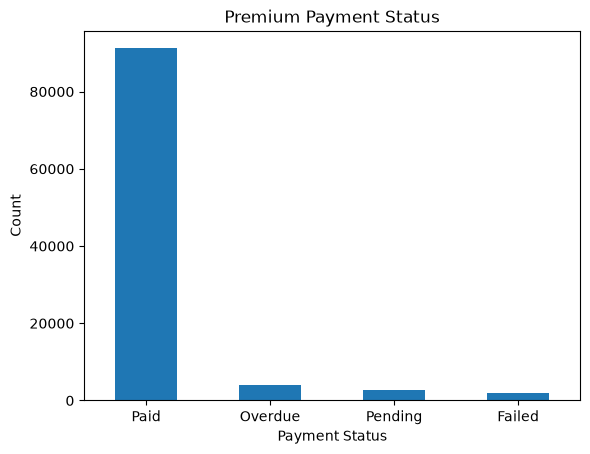

In [30]:
# Plot payment status
premiums["PAYMENT_STATUS"].value_counts().plot(kind="bar")

plt.title("Premium Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [31]:
# Payment delay summary
premiums["PAYMENT_DELAY_DAYS"].describe()

count    91161.000000
mean         6.744704
std          8.159359
min          0.000000
25%          0.000000
50%          4.000000
75%         12.000000
max         60.000000
Name: PAYMENT_DELAY_DAYS, dtype: float64

In [32]:
# Average delay by payment status
premiums.groupby("PAYMENT_STATUS")["PAYMENT_DELAY_DAYS"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
PAYMENT_STATUS,,,,,
Failed,0,NaN,NaN,NaN,NaN
Overdue,0,NaN,NaN,NaN,NaN
Paid,91161,6.744704,4.0,0.0,60.0
Pending,0,NaN,NaN,NaN,NaN


In [33]:
# Average delay by payment status
premiums.groupby("PAYMENT_STATUS")["PAYMENT_DELAY_DAYS"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
PAYMENT_STATUS,,,,,
Failed,0,NaN,NaN,NaN,NaN
Overdue,0,NaN,NaN,NaN,NaN
Paid,91161,6.744704,4.0,0.0,60.0
Pending,0,NaN,NaN,NaN,NaN


In [34]:
# Premium amount summary
premiums["PREMIUM_AMOUNT"].describe()

count    100000.000000
mean      10669.340050
std       12771.211033
min         100.000000
25%        1661.000000
50%        5886.500000
75%       15234.000000
max      148331.000000
Name: PREMIUM_AMOUNT, dtype: float64

In [35]:
# Missing paid dates by payment status
premiums.groupby("PAYMENT_STATUS")["PAID_DATE"].apply(
    lambda x: x.isnull().sum()
)

PAYMENT_STATUS
Failed     2014
Overdue    3979
Paid          0
Pending    2846
Name: PAID_DATE, dtype: int64

In [36]:
# Check underwriting decision distribution
underwriting["DECISION"].value_counts()

DECISION
Approved                 41717
Approved with Loading     6746
Declined                  1537
Name: count, dtype: int64

In [37]:
# Decision percentage
underwriting["DECISION"].value_counts(normalize=True) * 100

DECISION
Approved                 83.434
Approved with Loading    13.492
Declined                  3.074
Name: proportion, dtype: float64

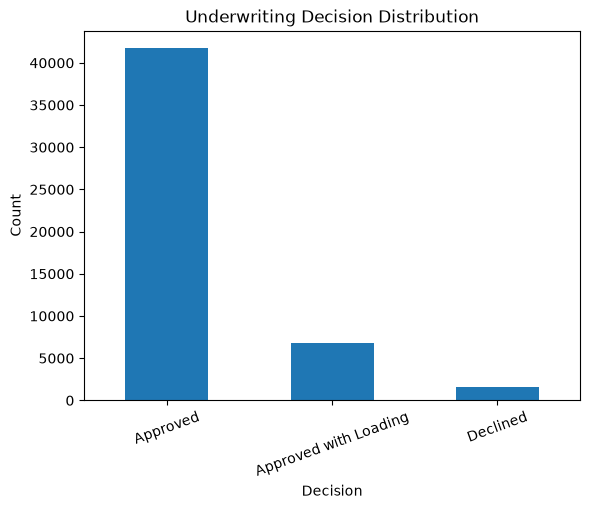

In [38]:
# Plot underwriting decision distribution
underwriting["DECISION"].value_counts().plot(kind="bar")

plt.title("Underwriting Decision Distribution")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

In [39]:
# Underwriting score summary by decision
underwriting.groupby("DECISION")["UNDERWRITING_SCORE"].describe()

,count,mean,std,min,25%,50%,75%,max
DECISION,,,,,,,,
Approved,41717.0,630.757461,67.355094,520.0,577.0,624.0,676.0,883.0
Approved with Loading,6746.0,487.516751,22.097669,440.0,470.0,491.0,507.0,519.0
Declined,1537.0,403.610930,31.683918,224.0,388.0,412.0,428.0,439.0


In [40]:
# Premium loading summary by underwriting decision
underwriting.groupby("DECISION")["PREMIUM_LOADING_PCT"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
DECISION,,,,,
Approved,41717,0.000000,0.00,0.0,0.0
Approved with Loading,6746,35.077951,35.15,10.0,60.0
Declined,0,NaN,NaN,NaN,NaN


In [41]:
# Summary of all numeric underwriting features
underwriting.select_dtypes(include=np.number).describe()

,AGE,HEALTH_SCORE,BMI,CREDIT_SCORE,UNDERWRITING_SCORE,PREMIUM_LOADING_PCT
count,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,48463.000000
mean,38.66618,75.86380,25.503648,719.397020,604.448940,4.882815
std,11.47019,12.18674,4.723345,69.570649,86.856855,13.299543
min,18.00000,23.00000,16.000000,450.000000,224.000000,0.000000
25%,30.00000,68.00000,22.200000,672.000000,546.000000,0.000000
50%,38.00000,76.00000,25.400000,720.000000,605.000000,0.000000
75%,47.00000,84.00000,28.700000,766.000000,664.000000,0.000000
max,80.00000,100.00000,42.000000,900.000000,883.000000,60.000000


In [42]:
# Function to count outliers using IQR method
def count_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return len(outliers)

In [43]:
# Check outliers in important numeric columns
print("Income Outliers:",
      count_outliers(customers, "ANNUAL_INCOME"))

print("Premium Outliers:",
      count_outliers(policies, "ANNUAL_PREMIUM"))

print("Claim Amount Outliers:",
      count_outliers(claims, "CLAIM_AMOUNT"))

Income Outliers: 5466
Premium Outliers: 11052
Claim Amount Outliers: 8022


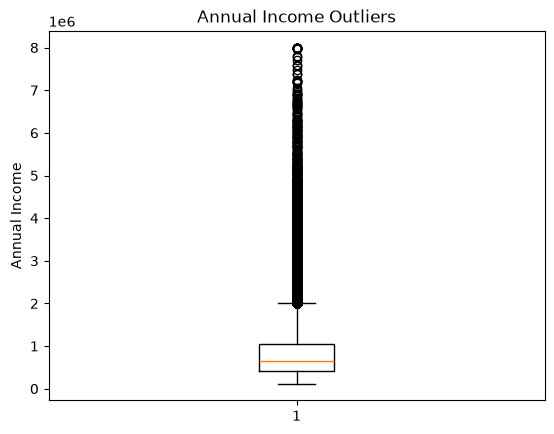

In [44]:
# Boxplot for annual income
plt.boxplot(customers["ANNUAL_INCOME"].dropna())

plt.title("Annual Income Outliers")
plt.ylabel("Annual Income")
plt.show()

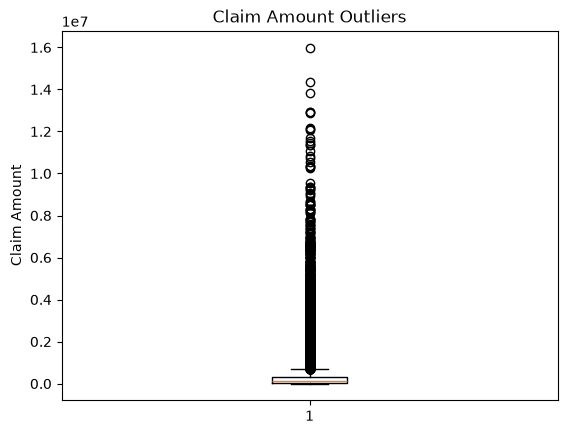

In [45]:
# Boxplot for claim amount
plt.boxplot(claims["CLAIM_AMOUNT"].dropna())

plt.title("Claim Amount Outliers")
plt.ylabel("Claim Amount")
plt.show()

In [46]:
# Select numeric customer features
customer_numeric = customers[
    [
        "AGE",
        "ANNUAL_INCOME",
        "CREDIT_SCORE"
    ]
]

# Calculate correlation matrix
customer_numeric.corr()

,AGE,ANNUAL_INCOME,CREDIT_SCORE
AGE,1.000000,-0.005111,0.006504
ANNUAL_INCOME,-0.005111,1.000000,0.005145
CREDIT_SCORE,0.006504,0.005145,1.000000


In [47]:
# Correlation between important policy numeric features
policy_numeric = policies[
    [
        "SUM_INSURED",
        "ANNUAL_PREMIUM",
        "RISK_SCORE",
        "DISCOUNT_PCT",
        "COMMISSION_PCT"
    ]
]

policy_numeric.corr()

,SUM_INSURED,ANNUAL_PREMIUM,RISK_SCORE,DISCOUNT_PCT,COMMISSION_PCT
SUM_INSURED,1.000000,0.368601,-0.001117,0.002431,0.000439
ANNUAL_PREMIUM,0.368601,1.000000,0.000567,0.000758,0.000787
RISK_SCORE,-0.001117,0.000567,1.000000,-0.003401,-0.000613
DISCOUNT_PCT,0.002431,0.000758,-0.003401,1.000000,-0.001680
COMMISSION_PCT,0.000439,0.000787,-0.000613,-0.001680,1.000000


In [48]:
# Correlation between numeric claim features
claim_numeric = claims.select_dtypes(include=np.number)

claim_numeric.corr()

,CLAIM_AMOUNT,SETTLEMENT_AMOUNT,PROCESSING_DAYS,FRAUD_SCORE
CLAIM_AMOUNT,1.000000,0.831381,-0.000485,-0.003199
SETTLEMENT_AMOUNT,0.831381,1.000000,-0.002678,-0.003475
PROCESSING_DAYS,-0.000485,-0.002678,1.000000,0.003921
FRAUD_SCORE,-0.003199,-0.003475,0.003921,1.000000
